# Lab CS4085

In [ ]:
import copy

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

In [ ]:
# =====================================================================
#  LAB SETUP - run this cell first, and do not edit it.
#
#  This lab is self-contained. The dataset loader and the automatic
#  checks used to come from the Coursera files `lr_utils.py` and
#  `public_tests.py`; they are defined here instead, so the notebook
#  runs in Google Colab, Anaconda / JupyterLab, or any plain Python
#  environment with no extra files to download.
#
#  Needs only: numpy, matplotlib, h5py, pillow  (all are preinstalled
#  in Colab and Anaconda). If h5py is missing, run in a cell:
#      !pip install h5py
# =====================================================================

import os
import urllib.request

import numpy as np

DATA_DIR = "datasets"
DATASET_SOURCE = None          # set by load_dataset(): "cats" or "stand-in"

_MIRRORS = [
    "https://raw.githubusercontent.com/dangnam739/deep-learning-coursera/master/"
    "Neural%20Networks%20and%20Deep%20Learning/Week%202%20-%20Neural%20Networks%20Basics/"
    "Exercise/datasets",
    "https://raw.githubusercontent.com/liqiang311/deeplearning.ai/master/"
    "1_Neural%20Networks%20and%20Deep%20Learning/week2/"
    "Logistic%20Regression%20as%20a%20Neural%20Network/datasets",
    "https://raw.githubusercontent.com/JudasDie/deeplearning.ai/master/"
    "Improving%20Deep%20Neural%20Networks/Week1/Regularization/datasets",
]


def _fetch(filename, timeout=60):
    """Return a local path to `filename`, downloading it once if needed."""
    os.makedirs(DATA_DIR, exist_ok=True)
    local = os.path.join(DATA_DIR, filename)
    if os.path.exists(local) and os.path.getsize(local) > 100000:
        return local
    last_error = None
    for base in _MIRRORS:
        try:
            with urllib.request.urlopen(base + "/" + filename, timeout=timeout) as response:
                data = response.read()
            if not data.startswith(b"\x89HDF"):
                raise ValueError("downloaded file is not an HDF5 file")
            with open(local, "wb") as handle:
                handle.write(data)
            return local
        except Exception as error:          # try the next mirror
            last_error = error
    raise RuntimeError("could not download %s (%s)" % (filename, last_error))


def _stand_in_dataset(m_train=209, m_test=50, num_px=64, seed=1):
    """Offline substitute with exactly the same shapes as the cat dataset.

    Used only when the notebook has no internet access, so the rest of the
    lab still runs. Class 1 images contain a coloured blob; class 0 images
    do not.
    """
    rng = np.random.default_rng(seed)
    rows, cols = np.mgrid[0:num_px, 0:num_px]

    def build(m):
        y = rng.integers(0, 2, size=m)
        x = rng.integers(55, 125, size=(m, num_px, num_px, 3)).astype(np.int16)
        x += rng.integers(-15, 16, size=(m, 1, 1, 3))           # per-image tint
        for i in range(m):
            if y[i] == 1:
                cy, cx = rng.integers(18, num_px - 18, size=2)
                radius = rng.integers(10, 17)
                blob = (rows - cy) ** 2 + (cols - cx) ** 2 < radius ** 2
                x[i][blob] += np.array([95, 45, -25], dtype=np.int16)
        x = np.clip(x, 0, 255).astype(np.uint8)
        return x, y.reshape(1, m)

    train_x, train_y = build(m_train)
    test_x, test_y = build(m_test)
    classes = np.array([b"non-cat", b"cat"])
    return train_x, train_y, test_x, test_y, classes


def load_dataset():
    """Load the cat / non-cat dataset (downloads it once into ./datasets)."""
    global DATASET_SOURCE
    import h5py
    try:
        train_path = _fetch("train_catvnoncat.h5")
        test_path = _fetch("test_catvnoncat.h5")
        with h5py.File(train_path, "r") as f:
            train_set_x_orig = np.array(f["train_set_x"][:])
            train_set_y_orig = np.array(f["train_set_y"][:])
            classes = np.array(f["list_classes"][:])
        with h5py.File(test_path, "r") as f:
            test_set_x_orig = np.array(f["test_set_x"][:])
            test_set_y_orig = np.array(f["test_set_y"][:])
        train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
        test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
        DATASET_SOURCE = "cats"
        print("Cat / non-cat dataset ready (files kept in ./%s)." % DATA_DIR)
        return (train_set_x_orig, train_set_y_orig,
                test_set_x_orig, test_set_y_orig, classes)
    except Exception as error:
        DATASET_SOURCE = "stand-in"
        print("Could not obtain the cat / non-cat files: %s" % error)
        print("No internet access? Using an offline stand-in dataset with the")
        print("same shapes so the rest of the lab still runs normally.")
        return _stand_in_dataset()


# --- check for Exercise 2 (replaces the hard-coded Coursera assertions) ------

_FIRST_10_TRAIN = [196, 192, 190, 193, 186, 182, 188, 179, 174, 213]
_FIRST_10_TEST = [115, 110, 111, 137, 129, 129, 155, 146, 145, 159]


def check_flatten(train_flat, test_flat, train_orig, test_orig):
    """Verify that the images were flattened column-wise."""
    for flat, orig, name in ((train_flat, train_orig, "train"),
                             (test_flat, test_orig, "test")):
        wanted = (orig.shape[1] * orig.shape[2] * orig.shape[3], orig.shape[0])
        assert flat.shape == wanted, (
            "%s_set_x_flatten should have shape %s but has %s. "
            "Use (X.shape[0], -1).T" % (name, wanted, flat.shape))
        assert np.array_equal(flat[:, 1], orig[1].reshape(-1)), (
            "Every column of %s_set_x_flatten must be one flattened image. "
            "Use (X.shape[0], -1).T" % name)
    if DATASET_SOURCE == "cats":
        assert np.all(train_flat[0:10, 1] == _FIRST_10_TRAIN), "Wrong solution. Use (X.shape[0], -1).T."
        assert np.all(test_flat[0:10, 1] == _FIRST_10_TEST), "Wrong solution. Use (X.shape[0], -1).T."
    print("\033[92mReshaping is correct.\033[0m")


print("Lab setup loaded.")

Lab setup loaded.


In [ ]:
# =====================================================================
#  AUTOMATIC CHECKS - run this cell, and do not edit it.
#  These replace the Coursera file `public_tests.py`.
#  Each test prints "All tests passed." or raises an error telling you
#  what is wrong with your function.
# =====================================================================

import copy as _copy

_OK = "\033[92mAll tests passed.\033[0m"


def sigmoid_test(target):
    assert np.allclose(target(np.array([0, 2])), [0.5, 0.88079708]), \
        "sigmoid([0, 2]) should be [0.5, 0.88079708]"
    assert np.allclose(target(0), 0.5), "sigmoid(0) should be 0.5"
    z = np.array([[-1.0, 0.0], [2.0, 3.5]])
    expected = np.array([[0.26894142, 0.5], [0.88079708, 0.97068777]])
    out = target(z)
    assert isinstance(out, np.ndarray) and out.shape == z.shape, \
        "sigmoid must keep the shape of its input - use np.exp, not math.exp"
    assert np.allclose(out, expected), "sigmoid is wrong on a 2-D array"
    assert np.allclose(target(np.array([-500.0, 500.0])), [0.0, 1.0]), \
        "sigmoid should saturate to 0 and 1 for large |z|"
    print(_OK)


def initialize_with_zeros_test_1(target):
    w, b = target(3)
    assert isinstance(w, np.ndarray), "w must be a numpy array"
    assert w.shape == (3, 1), "w should have shape (3, 1) but has %s" % (w.shape,)
    assert np.allclose(w, 0), "w must contain only zeros"
    assert type(b) == float, "b must be a python float (write 0.0, not np.zeros(1))"
    assert b == 0.0, "b must be 0.0"
    print(_OK)


def initialize_with_zeros_test_2(target):
    w, b = target(4)
    assert w.shape == (4, 1), "w should have shape (4, 1) but has %s" % (w.shape,)
    assert np.allclose(w, 0) and b == 0.0, "w must be all zeros and b must be 0.0"
    assert w.dtype == float, "w should hold floats"
    w2, _ = target(1)
    assert w2.shape == (1, 1), "initialize_with_zeros(1) should give w of shape (1, 1)"
    print(_OK)


def propagate_test(target):
    w = np.array([[1.0], [2.0]])
    b = 1.5
    X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
    Y = np.array([[1, 1, 0]])
    grads, cost = target(w, b, X, Y)
    assert isinstance(grads, dict) and "dw" in grads and "db" in grads, \
        "propagate must return a dict with keys 'dw' and 'db'"
    assert grads["dw"].shape == w.shape, "dw must have the same shape as w"
    assert np.allclose(grads["dw"], [[0.25071532], [-0.06604096]]), "dw is wrong"
    assert np.allclose(grads["db"], -0.12500405), "db is wrong"
    assert np.allclose(cost, 0.15900538), "cost is wrong"
    assert np.ndim(cost) == 0, "cost must be a scalar"

    w = np.array([[0.3], [-0.5], [0.8]])
    b = -0.2
    X = np.array([[1.0, 2.0, -1.0, 0.0], [0.5, -1.0, 2.0, 1.0], [-1.0, 0.0, 1.0, 2.0]])
    Y = np.array([[1, 0, 1, 0]])
    grads, cost = target(w, b, X, Y)
    assert np.allclose(grads["dw"], [[0.3422429], [-0.42423328], [0.3687066]]), \
        "dw is wrong on the second test (check the 1/m factor and X(A-Y).T)"
    assert np.allclose(grads["db"], 0.00814901), "db is wrong on the second test"
    assert np.allclose(cost, 1.21561255), "cost is wrong on the second test"
    print(_OK)


def optimize_test(target):
    w = np.array([[1.0], [2.0]])
    b = 1.5
    X = np.array([[1.0, -2.0, -1.0], [3.0, 0.5, -3.2]])
    Y = np.array([[1, 1, 0]])
    w_backup = w.copy()

    params, grads, costs = target(w, b, X, Y, num_iterations=101,
                                  learning_rate=0.009, print_cost=False)

    assert np.allclose(w, w_backup), \
        "optimize must not modify the w it was given (that is what copy.deepcopy is for)"
    assert np.allclose(params["w"], [[0.80795802], [2.05125464]]), \
        "w was not updated correctly - check the update rule w = w - learning_rate * dw"
    assert np.allclose(params["b"], 1.59566877), "b was not updated correctly"
    assert np.allclose(grads["dw"], [[0.178049], [-0.04827102]]), "dw is wrong"
    assert np.allclose(grads["db"], -0.08860601), "db is wrong"
    assert len(costs) == 2, "costs should hold one value every 100 iterations"
    assert np.allclose(costs, [0.15900538, 0.10541138]), "the recorded costs are wrong"
    print(_OK)


def predict_test(target):
    w = np.array([[0.1124579], [0.23106775]])
    b = -0.3
    X = np.array([[1.0, -1.1, -3.2], [1.2, 2.0, 0.1]])
    pred = target(w, b, X)
    assert isinstance(pred, np.ndarray), "predict must return a numpy array"
    assert pred.shape == (1, X.shape[1]), \
        "predictions should have shape (1, m) but have %s" % (pred.shape,)
    assert np.all(np.isin(pred, [0, 1])), "predictions must be only 0 or 1"
    assert np.allclose(pred, [[1.0, 1.0, 0.0]]), "the predictions are wrong"

    zeros = target(np.zeros((2, 1)), 0.0, X)
    assert np.allclose(zeros, [[0.0, 0.0, 0.0]]), \
        "when the activation is exactly 0.5 the prediction must be 0 (use a > 0.5)"
    print(_OK)


def model_test(target):
    rng = np.random.default_rng(0)
    X_train = rng.normal(size=(4, 20))
    Y_train = (np.sum(X_train, axis=0, keepdims=True) > 0).astype(float)
    X_test = rng.normal(size=(4, 8))
    Y_test = (np.sum(X_test, axis=0, keepdims=True) > 0).astype(float)

    d = target(X_train, Y_train, X_test, Y_test,
               num_iterations=250, learning_rate=0.1, print_cost=False)

    for key in ("costs", "Y_prediction_test", "Y_prediction_train",
                "w", "b", "learning_rate", "num_iterations"):
        assert key in d, "the returned dictionary is missing the key '%s'" % key
    assert d["w"].shape == (4, 1), "w should have shape (4, 1) but has %s" % (d["w"].shape,)
    assert d["Y_prediction_train"].shape == Y_train.shape, \
        "Y_prediction_train has the wrong shape"
    assert d["Y_prediction_test"].shape == Y_test.shape, \
        "Y_prediction_test has the wrong shape"
    assert len(d["costs"]) == 3, "costs should hold one value every 100 iterations"
    assert np.allclose(d["costs"][0], 0.69314718), \
        "the first cost should be log(2) - did you initialise w and b with zeros?"
    assert d["costs"][-1] < d["costs"][0], "the cost should go down during training"
    assert np.allclose(d["w"], [[1.59854283], [1.61867667], [1.69085271], [1.12722706]]), \
        "the learned w is wrong - check the order of the steps inside model()"
    assert np.allclose(d["b"], 0.02069309), "the learned b is wrong"
    train_acc = 100 - np.mean(np.abs(d["Y_prediction_train"] - Y_train)) * 100
    test_acc = 100 - np.mean(np.abs(d["Y_prediction_test"] - Y_test)) * 100
    assert train_acc == 100.0 and test_acc == 100.0, \
        "the model should separate this easy toy dataset perfectly"
    print(_OK)


print("Checks loaded: sigmoid_test, initialize_with_zeros_test_1/2, "
      "propagate_test, optimize_test, predict_test, model_test")

Checks loaded: sigmoid_test, initialize_with_zeros_test_1/2, propagate_test, optimize_test, predict_test, model_test


# overview the problem set


In [ ]:
# Loading the data (cat/non-cat)
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

Cat / non-cat dataset ready (files kept in ./datasets).


y = [1], it's a 'cat' picture.


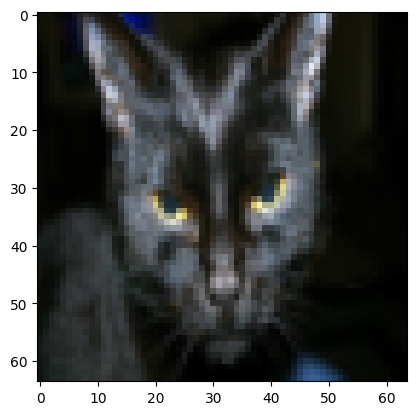

In [ ]:
# Example of a picture
index = 25
plt.imshow(train_set_x_orig[index])
print ("y = " + str(train_set_y[:, index]) + ", it's a '" + classes[np.squeeze(train_set_y[:, index])].decode("utf-8") +  "' picture.")

## Understanding my data

In [ ]:
#(≈ 3 lines of code)
# m_train =
# m_test =
# num_px =
# YOUR CODE STARTS HERE
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]
num_px = train_set_x_orig.shape[1]
# YOUR CODE ENDS HERE

print ("Number of training examples: m_train = " + str(m_train))
print ("Number of testing examples: m_test = " + str(m_test))
print ("Height/Width of each image: num_px = " + str(num_px))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")

print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x shape: " + str(test_set_x_orig.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Number of training examples: m_train = 209
Number of testing examples: m_test = 50
Height/Width of each image: num_px = 64
Each image is of size: (64, 64, 3)
train_set_y shape: (1, 209)
test_set_x shape: (50, 64, 64, 3)
test_set_y shape: (1, 50)


## change to vector reshape and tranpose

In [ ]:
# Reshape the training and test examples
#(≈ 2 lines of code)
# train_set_x_flatten = ...
# test_set_x_flatten = ...
# YOUR CODE STARTS HERE
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T

# Check that each image has become one column
check_flatten(train_set_x_flatten, test_set_x_flatten,
              train_set_x_orig, test_set_x_orig)

print ("train_set_x_flatten shape: " + str(train_set_x_flatten.shape))
print ("train_set_y shape: " + str(train_set_y.shape))
print ("test_set_x_flatten shape: " + str(test_set_x_flatten.shape))
print ("test_set_y shape: " + str(test_set_y.shape))

Reshaping is correct.
train_set_x_flatten shape: (12288, 209)
train_set_y shape: (1, 209)
test_set_x_flatten shape: (12288, 50)
test_set_y shape: (1, 50)


12288 is number of rows and 209 number of pictures

## standarize the data set

In [ ]:
train_set_x = train_set_x_flatten / 255.
test_set_x = test_set_x_flatten / 255.

standarize to make the numbers between 0 and 1

## creating Model

### Creating the sigmoid function

In [ ]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s
#print ("sigmoid ([0, 2]) =" + str(sigmoid(np.array([0, 2]))))


## initialized of my parameter

In [ ]:
def initialize_with_zeros(dim):
  w = np.zeros((dim, 1))
  b = 0.0

  return w,b

In [ ]:
dim = 2
w, b = initialize_with_zeros(dim)

assert type(b) == float
print ("w = " + str(w))
print ("b = " + str(b))

initialize_with_zeros_test_1(initialize_with_zeros)
initialize_with_zeros_test_2(initialize_with_zeros)


w = [[0.]
 [0.]]
b = 0.0
All tests passed.
All tests passed.


### calculate the cost function

In [ ]:
def propogate(w,b,X,Y):
  #forward propagation
  A = sigmoid(np.dot(w.T, X) + b) #activiation is give me the pridected y
  m = X.shape[1]
  cost = -1/ m * np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A)) #cross-enter

  # Backward propagation
  dw = 1/m * np.dot(X, (A - Y).T)
  db = 1/m * np.sum(A - Y)
  grads = {
        "dw": dw,
        "db": db
    }
  cost = np.squeeze(np.array(cost))
  return grads, cost


## optimization

In [ ]:
# GRADED FUNCTION: optimize

def optimize(w, b, X, Y, num_iterations=100, learning_rate=0.009, print_cost=False):
    """
    This function optimizes w and b by running a gradient descent algorithm
    """

    w = copy.deepcopy(w)
    b = copy.deepcopy(b)

    costs = []

    for i in range(num_iterations):

        # Cost and gradient calculation
        # YOUR CODE STARTS HERE
        grads, cost = propogate(w, b, X, Y)
        # YOUR CODE ENDS HERE

        # Retrieve derivatives from grads
        dw = grads["dw"]
        db = grads["db"]

        # Update rule
        # YOUR CODE STARTS HERE
        w = w - learning_rate * dw
        b = b - learning_rate * db
        # YOUR CODE ENDS HERE

        # Record the costs
        if i % 100 == 0:
            costs.append(cost)

            # Print the cost every 100 iterations
            if print_cost:
                print("Cost after iteration %i: %f" % (i, cost))

    params = {
        "w": w,
        "b": b
    }

    grads = {
        "dw": dw,
        "db": db
    }

    return params, grads, costs

In [ ]:
# Re-initialize w and b with the correct dimension from the training data
init_dim = train_set_x.shape[0]
w, b = initialize_with_zeros(init_dim)

# Call optimize with the correct training data
params, grads, costs = optimize(w, b, train_set_x, train_set_y, num_iterations=100, learning_rate=0.009, print_cost=False)

print ("w = " + str(params["w"]))
print ("b = " + str(params["b"]))
print ("dw = " + str(grads["dw"]))
print ("db = " + str(grads["db"]))
print("Costs = " + str(costs))

optimize_test(optimize)

w = [[ 0.00371347]
 [-0.00580846]
 [-0.00243599]
 ...
 [-0.00415961]
 [-0.00941159]
 [ 0.00372733]]
b = -0.004064524049290153
dw = [[0.05732876]
 [0.06275264]
 [0.05601604]
 ...
 [0.05429732]
 [0.0560881 ]
 [0.0392286 ]]
db = 0.1389566871056701
Costs = [array(0.69314718)]
All tests passed.


## predict is cat or not

In [ ]:
# GRADED FUNCTION: predict

def predict(w, b, X):
    """
    Predict whether the label is 0 or 1 using learned
    logistic regression parameters (w, b)
    """

    m = X.shape[1]
    Y_prediction = np.zeros((1, m))

    w = w.reshape(X.shape[0], 1)

    # YOUR CODE STARTS HERE

    A = sigmoid(np.dot(w.T, X) + b)

    # YOUR CODE ENDS HERE

    for i in range(A.shape[1]):

        # YOUR CODE STARTS HERE

      if i in range (A.shape[1]):
        if A[0, i] > 0.5:
          Y_prediction[0, i] = 1
        else:
          Y_prediction[0, i] = 0

        # YOUR CODE ENDS HERE

    return Y_prediction

In [ ]:
w = np.array([[0.1124579], [0.23106775]])
b = -0.3
X = np.array([[1., -1.1, -3.2],[1.2, 2., 0.1]])
print ("predictions = " + str(predict(w, b, X)))

predict_test(predict)

predictions = [[1. 1. 0.]]
All tests passed.


# Merge all functions into a model

## model

In [ ]:
# GRADED FUNCTION: model

def model(X_train, Y_train, X_test, Y_test,
          num_iterations=2000,
          learning_rate=0.5,
          print_cost=False):

    # YOUR CODE STARTS HERE

    # Initialize parameters
    w, b = initialize_with_zeros(X_train.shape[0])

    # Optimize parameters
    params, grads, costs = optimize(
        w, b, X_train, Y_train,
        num_iterations,
        learning_rate,
        print_cost
    )

    # Retrieve learned parameters
    w = params["w"]
    b = params["b"]

    # Predict train and test sets
    Y_prediction_train = predict(w, b, X_train)
    Y_prediction_test = predict(w, b, X_test)

    # YOUR CODE ENDS HERE

    # Print train/test Errors
    if print_cost:
        print("train accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_train - Y_train)) * 100
        ))
        print("test accuracy: {} %".format(
            100 - np.mean(np.abs(Y_prediction_test - Y_test)) * 100
        ))

    d = {
        "costs": costs,
        "Y_prediction_test": Y_prediction_test,
        "Y_prediction_train": Y_prediction_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations
    }

    return d

In [ ]:
model_test(model)

All tests passed.


In [ ]:
logistic_regression_model = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=2000, learning_rate=0.005, print_cost=True)

Cost after iteration 0: 0.693147
Cost after iteration 100: 0.584508
Cost after iteration 200: 0.466949
Cost after iteration 300: 0.376007
Cost after iteration 400: 0.331463
Cost after iteration 500: 0.303273
Cost after iteration 600: 0.279880
Cost after iteration 700: 0.260042
Cost after iteration 800: 0.242941
Cost after iteration 900: 0.228004
Cost after iteration 1000: 0.214820
Cost after iteration 1100: 0.203078
Cost after iteration 1200: 0.192544
Cost after iteration 1300: 0.183033
Cost after iteration 1400: 0.174399
Cost after iteration 1500: 0.166521
Cost after iteration 1600: 0.159305
Cost after iteration 1700: 0.152667
Cost after iteration 1800: 0.146542
Cost after iteration 1900: 0.140872
train accuracy: 99.04306220095694 %
test accuracy: 70.0 %


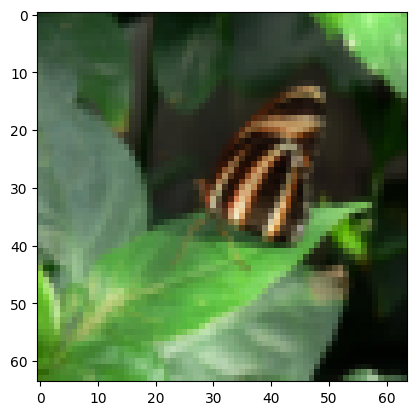

y = 0, you predicted that it is a "cat" picture.


In [ ]:
# Example of a picture that was wrongly classified.
index = 5   # Other options you could try: 6, 10, 11, 13

plt.imshow(test_set_x[:, index].reshape((num_px, num_px, 3)))
plt.show()
print ("y = " + str(test_set_y[0, index]) + ", you predicted that it is a \"" +
       classes[int(logistic_regression_model['Y_prediction_test'][0, index])].decode("utf-8") +
       "\" picture.")

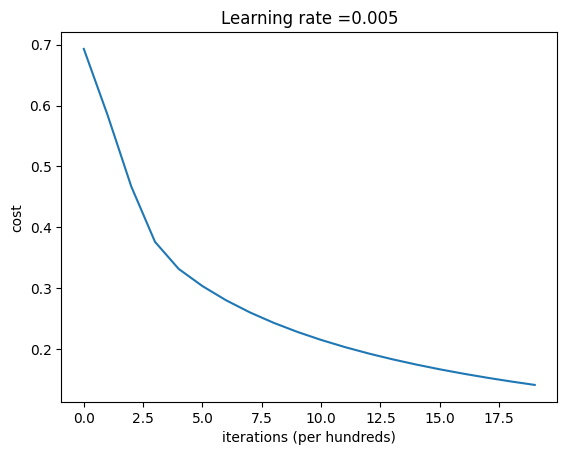

In [ ]:
# Plot learning curve (with costs)
costs = np.squeeze(logistic_regression_model['costs'])
plt.plot(costs)
plt.ylabel('cost')
plt.xlabel('iterations (per hundreds)')
plt.title("Learning rate =" + str(logistic_regression_model["learning_rate"]))
plt.show()

Training a model with learning rate: 0.01

-------------------------------------------------------

Training a model with learning rate: 0.001

-------------------------------------------------------

Training a model with learning rate: 0.0001

-------------------------------------------------------



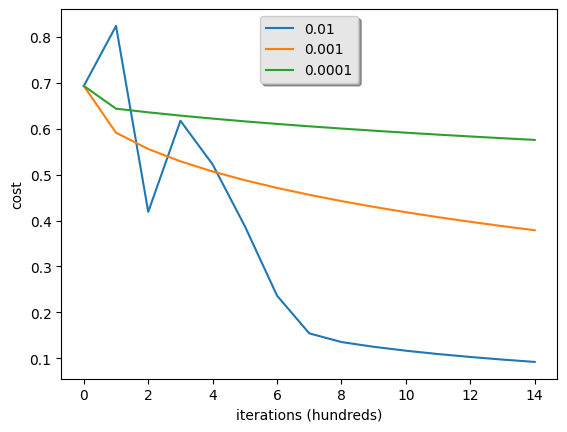

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
models = {}

for lr in learning_rates:
    print ("Training a model with learning rate: " + str(lr))
    models[str(lr)] = model(train_set_x, train_set_y, test_set_x, test_set_y, num_iterations=1500, learning_rate=lr, print_cost=False)
    print ('\n' + "-------------------------------------------------------" + '\n')

for lr in learning_rates:
    plt.plot(np.squeeze(models[str(lr)]["costs"]), label=str(models[str(lr)]["learning_rate"]))

plt.ylabel('cost')
plt.xlabel('iterations (hundreds)')

legend = plt.legend(loc='upper center', shadow=True)
frame = legend.get_frame()
frame.set_facecolor('0.90')
plt.show()

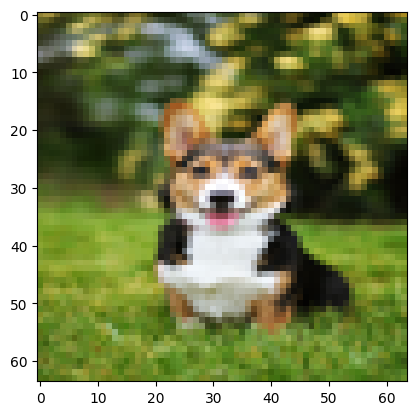

y = 0.0, your algorithm predicts a "non-cat" picture.


In [ ]:
import os

# change this to the name of your own image file
my_image = "/content/cute-dog-1.jpg"

if not os.path.exists(my_image):
    print("No file named '%s' next to this notebook, so there is nothing to "
          "classify." % my_image)
    print("Upload an image, put its file name in my_image above, and run this "
          "cell again.")
else:
    # We preprocess the image to fit your algorithm.
    image = np.array(Image.open(my_image).convert("RGB").resize((num_px, num_px)))
    plt.imshow(image)
    plt.show()

    image = image / 255.
    image = image.reshape((1, num_px * num_px * 3)).T
    my_predicted_image = predict(logistic_regression_model["w"],
                                 logistic_regression_model["b"], image)

    print("y = " + str(np.squeeze(my_predicted_image)) +
          ", your algorithm predicts a \"" +
          classes[int(np.squeeze(my_predicted_image))].decode("utf-8") +
          "\" picture.")